<a href="https://colab.research.google.com/github/AyatM711/CodVeda-_Intership/blob/main/level2_task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Task 3: Clustering Analysis (K-Means)

the Goal in this analysis is to  Group similar flowers together based on their measurements,
without using the species label (unsupervised learning).

#Dataset: iris.csv
Features used: sepal_length, sepal_width, petal_length, petal_width


#1.Firstly loading the dataset Features for clustering (we intentionally drop 'species' since clustering is unsupervised)


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_style("whitegrid")

# 1. Load the dataset

df = pd.read_csv("iris.csv")
print("Dataset shape:", df.shape)
print(df.head())
print("\nMissing values:\n", df.isnull().sum())
feature_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
X = df[feature_cols]


Dataset shape: (150, 5)
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Missing values:
 sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


# 2. Elbow method to determine optimal number of clusters

Saved plot: task3_elbow_method.png

Inertia values by k:
  k=1: 600.00
  k=2: 223.73
  k=3: 140.97
  k=4: 114.62
  k=5: 91.30
  k=6: 81.76
  k=7: 71.32
  k=8: 62.65
  k=9: 55.26
  k=10: 50.62


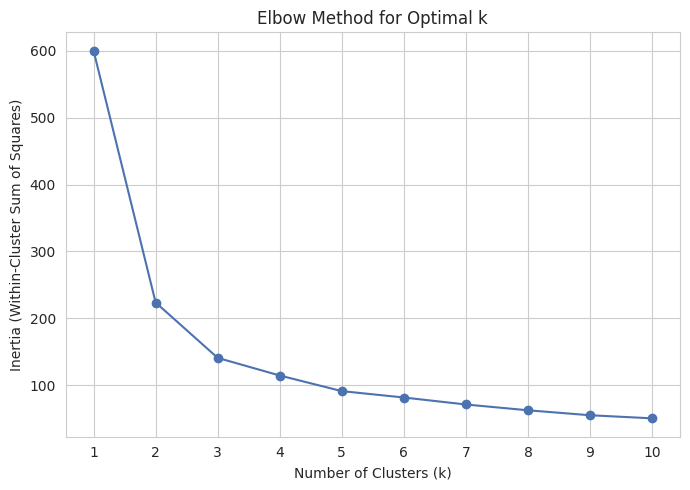

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(k_range, inertia, marker="o", color="#4C72B0")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.title("Elbow Method for Optimal k")
plt.xticks(list(k_range))
plt.tight_layout()
plt.savefig("task3_elbow_method.png", dpi=150)
print("Saved plot: task3_elbow_method.png")
print("\nInertia values by k:")
for k, i in zip(k_range, inertia):
    print(f"  k={k}: {i:.2f}")

# The elbow is clearly visible at k=3 (matches the 3 known iris species)
optimal_k = 3

3. Apply K-Means with the chosen k

In [7]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

print(f"\nApplied K-Means with k={optimal_k}")
print("\nCluster sizes:")
print(df["cluster"].value_counts().sort_index())

# Compare clusters to actual species (just for our own validation -
# in real unsupervised problems you wouldn't have this ground truth)
if "species" in df.columns:
    print("\nCluster vs actual species crosstab:")
    print(pd.crosstab(df["cluster"], df["species"]))


Applied K-Means with k=3

Cluster sizes:
cluster
0    53
1    50
2    47
Name: count, dtype: int64

Cluster vs actual species crosstab:
species  setosa  versicolor  virginica
cluster                               
0             0          39         14
1            50           0          0
2             0          11         36


# 5. Visualize clusters (2D scatter plots)

Saved plot: task3_cluster_scatterplots.png


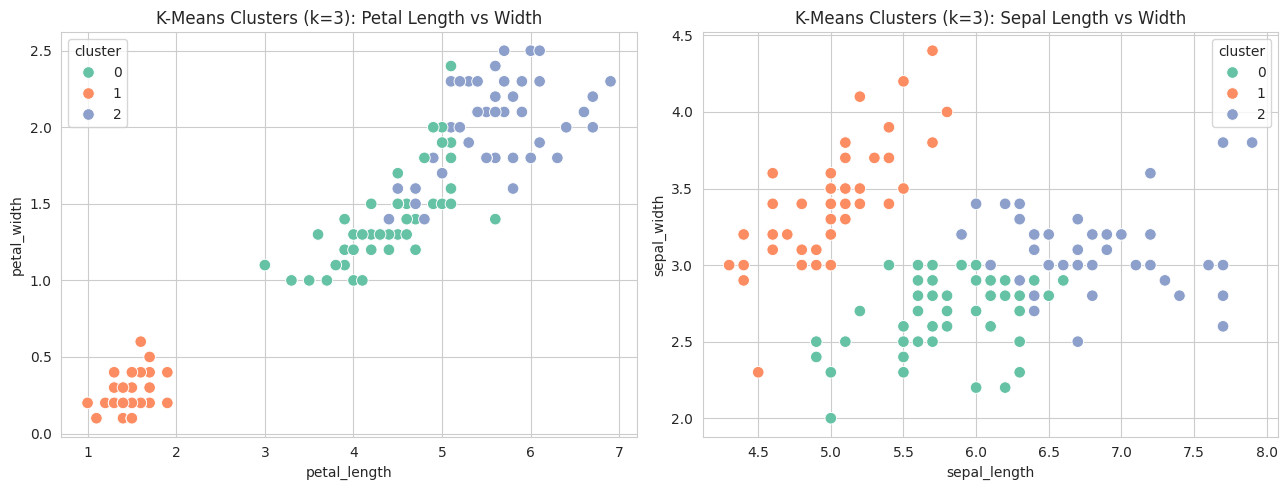

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Petal length vs petal width, colored by cluster
sns.scatterplot(
    data=df, x="petal_length", y="petal_width",
    hue="cluster", palette="Set2", s=70, ax=axes[0]
)
axes[0].set_title(f"K-Means Clusters (k={optimal_k}): Petal Length vs Width")

# Sepal length vs sepal width, colored by cluster
sns.scatterplot(
    data=df, x="sepal_length", y="sepal_width",
    hue="cluster", palette="Set2", s=70, ax=axes[1]
)
axes[1].set_title(f"K-Means Clusters (k={optimal_k}): Sepal Length vs Width")

plt.tight_layout()
plt.savefig("task3_cluster_scatterplots.png", dpi=150)
print("Saved plot: task3_cluster_scatterplots.png")